In [51]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

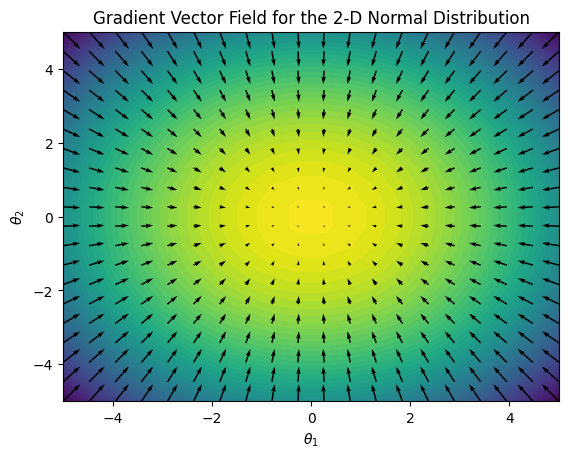

In [52]:
mu = jnp.array([0.,0.])
sig = jnp.array([[1.0,0.0],
                 [0.0,1.0]])

x = jnp.linspace(-5,5,20)
y = jnp.linspace(-5,5,20)

X,Y = jnp.meshgrid(x,y)

coordinates = jnp.concatenate((X[...,jnp.newaxis],Y[...,jnp.newaxis]),axis = -1)

def log_P(x):
    mu = jnp.array([0.,0.])
    sig = jnp.array([[1.0,0.0],
                 [0.0,1.0]])
    
    return jax.scipy.stats.multivariate_normal.logpdf(x,mu,sig)

grad_log_P = jax.vmap(jax.vmap(jax.grad(log_P)))

grads = grad_log_P(coordinates)

plt.title('Gradient Vector Field for the 2-D Normal Distribution')
plt.xlabel('$\\theta_1$')
plt.ylabel('$\\theta_2$')

plt.contourf(X,Y,log_P(coordinates),levels = 50)
plt.quiver(X,Y,grads[:,:,0],grads[:,:,1])
plt.savefig('fig2.png')

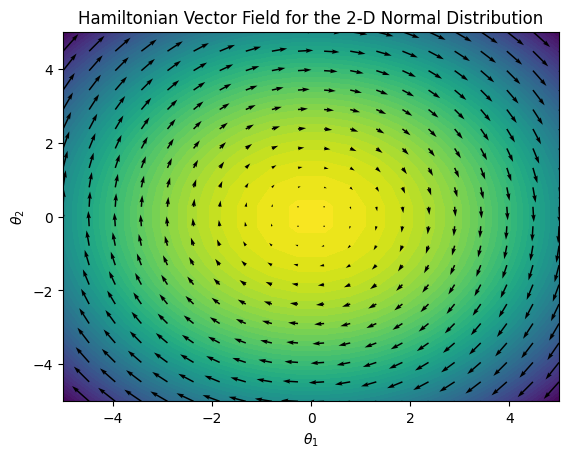

In [53]:
plt.title('Hamiltonian Vector Field for the 2-D Normal Distribution')
plt.xlabel('$\\theta_1$')
plt.ylabel('$\\theta_2$')

plt.contourf(X,Y,log_P(coordinates),levels = 50)
plt.quiver(X,Y,-grads[:,:,1],grads[:,:,0])
plt.savefig('fig3.png')